In [104]:
import numpy as np
import matplotlib.pyplot as plt

def initialize(size):
    x = np.zeros(size)
    y = np.zeros(size)
    for i in range(size):
        x[i] = -1+ ((i*2)/(size-1)) # position variables translated from indeces to positions
        y[i]=  -1+ ((i*2)/(size-1))
    potential = np.zeros((size,size)) #Zero potential inside
    for i in range(1,size-1): # Linear gradient between vertical plates
        potential[0][i] = -1+ ((i*2)/(size-1)) 
        potential[-1][i] = -1+ ((i*2)/(size-1)) 
    for i in range(0,size):
        potential[i][0] = -1
        potential[i][-1] = 1
    return x,y, potential

In [105]:
def initialize2(size,d):
    # distance d (integer) 
    # size (integer) must be odd
    x = np.zeros(size)
    y = np.zeros(size)
    for i in range(size):
        x[i] = -1+ ((i*2)/(size-1)) # position variables translated from indeces to positions
        y[i]=  -1+ ((i*2)/(size-1))
    potential = np.zeros((size,size)) #Zero potential inside
    centerx = int(size/2)
    centery = int(size/2)
    cap1 = np.array([[centerx-(d/2),centery],[centerx-(d/2),centery+1],[centerx-(d/2),centery-1]]).astype(int)
    cap2 = np.array([[centerx+(d/2),centery],[centerx+(d/2),centery+1],[centerx+(d/2),centery-1]]).astype(int)
    for i in range(0,size):
        potential[i][0] = 0
        potential[i][-1] = 0
        potential[0][i] = 0
        potential[-1][i]= 0
    for i,j in cap1:
        potential[j][i]=-10
    for i,j in cap2:
        potential[j,i]=10
    return x,y, potential,cap1,cap2
#x,y,potential, cap1,cap2 = initialize2(7,2)
#print(potential)


In [106]:
def update_pot(pot,size,deltaV):
    pot_new = np.zeros((size,size))
    for i in range(1,size-1):
        for j in range(1,size-1):
            pot_new[j][i] = pot[j][i]
    for i in range(1,size-1):
        for j in range(1,size-1):
            pot_new[j][i] = (0.25)*(pot[j+1][i] + pot[j-1][i]+pot[j][i-1]+pot[j][i+1])
            deltaV += (pot_new[j][i]-pot[j][i])
    for i in range(1,size-1):
        for j in range(1,size-1):
            pot[j][i] = pot_new[j][i]
    return pot, deltaV

In [107]:
def update_pot2(pot,size,deltaV,cap1,cap2):
    pot_new = np.zeros((size,size))
    for i in range(1,size-1):
        for j in range(1,size-1):
            pot_new[j][i] = pot[j][i]
    for i in range(1,size-1):
        for j in range(1,size-1):
            if np.any(np.all(cap1 == [i, j], axis=1)):
                pot_new[j][i] = -1
            elif np.any(np.all(cap2 == [i, j], axis=1)):
                pot_new[j][i] = 1
            else:
                pot_new[j][i] = (0.25)*(pot[j+1][i] + pot[j-1][i]+pot[j][i-1]+pot[j][i+1])
                deltaV += (pot_new[j][i]-pot[j][i])
    for i in range(1,size-1):
        for j in range(1,size-1):
            pot[j][i] = pot_new[j][i]
    return pot, deltaV

In [108]:
def relaxxxxx(pot,size):
    deltaV = 1
    kiter = 0
    while (deltaV > 0.02 and kiter < 90):
        pot, deltaV = update_pot(pot,size,deltaV)
        kiter += 1
    return pot
def relaxxxxx2(pot,size,cap1,cap2):
    deltaV = 1
    kiter = 0
    while (deltaV > 0.2 and kiter < 30):
        pot, deltaV = update_pot2(pot,size,deltaV,cap1,cap2)
        kiter += 1
    print(kiter)
    return pot

In [118]:
def calcE(size,x,y,pot,cap1,cap2):
    Ex = np.zeros((size,size))
    Ey = np.zeros((size,size))
    for i in range(1,size-1):
        for j in range(1,size-1):
            if np.any(np.all(cap1 == [i, j], axis=1)) or np.any(np.all(cap2 == [i, j], axis=1)):
                Ex[j][i] = 0
                Ey[j][i] = 0
            else:
                Ex[j][i] = -(pot[j,i+1]-pot[j,i-1])/(2*(x[i+1]-x[i]))/3
                Ey[j][i] = -(pot[j+1,i]-pot[j-1,i])/(2*(y[j+1]-y[j]))/3
    return Ex,Ey

30


C:\Users\Michael Bibbs\AppData\Local\Temp\ipykernel_61660\3938206990.py:5: RuntimeWarning: invalid value encountered in divide
  Ex_norm = Ex / np.sqrt(Ex**2+Ey**2)
C:\Users\Michael Bibbs\AppData\Local\Temp\ipykernel_61660\3938206990.py:6: RuntimeWarning: invalid value encountered in divide
  Ey_norm = Ey / np.sqrt(Ex**2+Ey**2)


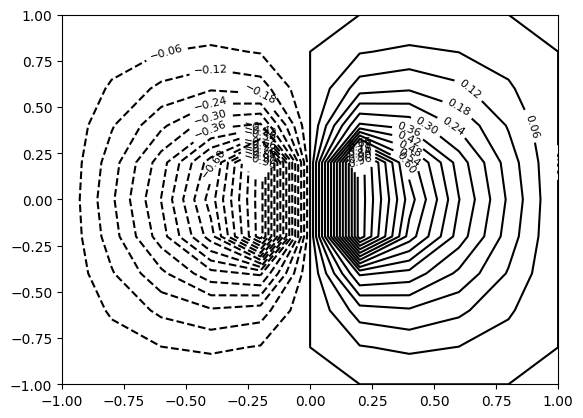

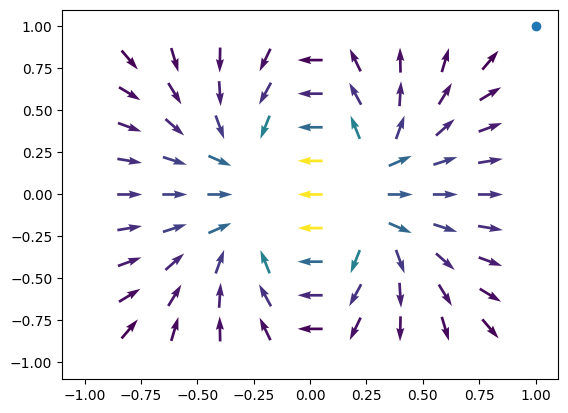

In [ ]:
def main(size,d):
    x,y,pot,cap1,cap2 = initialize2(size,d)
    pot = relaxxxxx2(pot,size,cap1,cap2)
    Ex,Ey = calcE(size,x,y,pot,cap1,cap2)
    Ex_norm = Ex / np.sqrt(Ex**2+Ey**2)
    Ey_norm = Ey / np.sqrt(Ex**2+Ey**2)
    
    C = np.hypot(Ex, Ey)

    #print(np.round(pot,2))
    Vplot = plt.contour(x,y,pot,35,colors="Black")
    plt.clabel(Vplot, inline=True,fontsize=8)
    plt.show()
    plt.quiver(x,y,Ex_norm,Ey_norm,C, pivot='mid')
main(11,2)

In [111]:
list1 = np.array([[1,2],[2,3],[4,5]])
list2 = np.array([[1,3],[3,3],[3,5]])
if [1,2] in list1 or list2:
    print("hello")

hello


In [112]:
rounded = np.round(initialize(11),2)
print(rounded)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (3, 11) + inhomogeneous part.